In [1]:
# Part I: Data Extraction

import pandas as pd

#  reload raw file
df = pd.read_csv("./output/jpm_retail_portfolio_raw.csv")

#  pivot to wide format
df_wide = df.pivot(index="Quarter", columns="Metric", values="Value").reset_index()

In [2]:
# Part II : Data Preparation

#  rename PPNR column
df_wide = df_wide.rename(columns={"Pre-provision profit": "PPNR"})

# convert quarter to time
df_wide["Year"] = df_wide["Quarter"].str[-2:].astype(int) + 2000
df_wide["Q"] = df_wide["Quarter"].str[0].astype(int)

df_wide["date"] = pd.PeriodIndex.from_fields(
    year=df_wide["Year"],
    quarter=df_wide["Q"],
    freq="Q"
).to_timestamp()

# sort by date
df_wide = df_wide.sort_values("date").reset_index(drop=True)

# create lagged PPNR
df_wide["PPNR_lag1"] = df_wide["PPNR"].shift(1)
df_wide["PPNR_lag2"] = df_wide["PPNR"].shift(2)

#  only drop rows missing these fields
df_model = df_wide.dropna(subset=["PPNR", "PPNR_lag1", "PPNR_lag2"]).copy()

#  convert numeric columns
df_model.columns.name = None
df_wide.columns.name = None

non_numeric_cols = ["Quarter", "Year", "Q", "date"]

for col in df_model.columns:
    if col not in non_numeric_cols:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

#  check result for init. variables
print(df_wide.shape)
print(df_model.shape)
df_model[["Quarter", "PPNR", "PPNR_lag1", "PPNR_lag2","Loans", "Deposits", "Total assets", "Nonperforming assets", "Net charge-offs"]].head()

AttributeError: type object 'PeriodIndex' has no attribute 'from_fields'

In [ ]:
# remove the pivot column label
df_model.columns.name = None

# make sure all model variables except identifiers are numeric
non_numeric_cols = ["Quarter", "Year", "Q", "date"]

for col in df_model.columns:
    if col not in non_numeric_cols:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# check whether PPNR is numeric
print(df_model["PPNR"].dtype)

# build correlation matrix first
corr_matrix = df_model.drop(columns=["Year", "Q"]).corr(numeric_only=True)

# then get correlation with PPNR
corr_with_ppnr = corr_matrix["PPNR"].sort_values(ascending=False)
print(corr_with_ppnr)

float64
PPNR                                                 1.000000
Total net revenue                                    0.968964
Common stockholders’ equity                          0.893840
Income before income tax expense                     0.887747
Long-term debt                                       0.875465
PPNR_lag1                                            0.867921
Loans                                                0.853883
Common equity Tier 1 (“CET1”) capital ratio          0.851409
Net income                                           0.849574
Total noninterest expense                            0.825118
Total assets                                         0.816575
Total capital ratio                                  0.802105
PPNR_lag2                                            0.789978
Tier 1 capital ratio                                 0.768999
Consumer net charge-off rate                         0.753160
Deposits                                             0.741982


In [ ]:
model_vars = [
    "date",   
    "PPNR",
    "PPNR_lag1",
    "PPNR_lag2",
    "Total assets",
    "Nonperforming assets",
    "Net charge-offs"
]

df_reg = df_model[model_vars].dropna().copy()

print(df_reg.head())

        date     PPNR  PPNR_lag1  PPNR_lag2  Total assets  \
2 2009-07-01  13167.0    12103.0    11652.0     2041009.0   
3 2009-10-01  11160.0    13167.0    12103.0     2031989.0   
4 2010-01-01  11547.0    11160.0    13167.0     2135796.0   
5 2010-04-01  10470.0    11547.0    11160.0     2014019.0   
6 2010-07-01   9426.0    10470.0    11547.0     2141595.0   

   Nonperforming assets  Net charge-offs  
2               20362.0           6373.0  
3               19741.0           6177.0  
4               19019.0           7910.0  
5               18156.0           5714.0  
6               17656.0           4945.0  


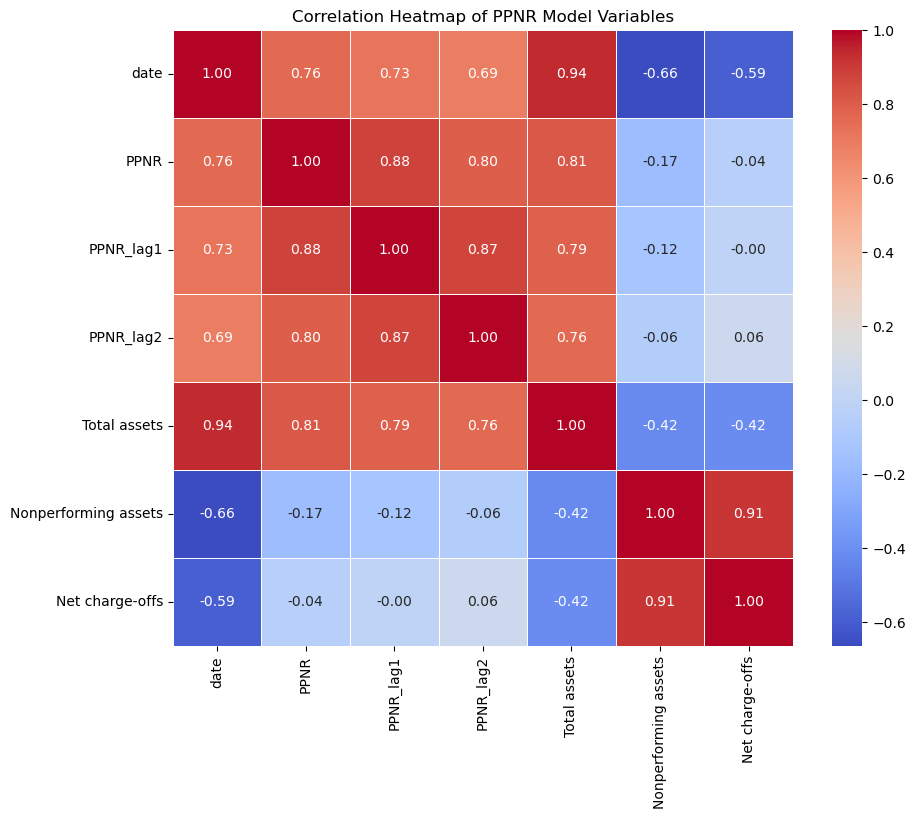

In [ ]:
# Init. heatmap
# checking corr for the variables

import seaborn as sns
import matplotlib.pyplot as plt

corr = df_reg.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, 
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap of PPNR Model Variables")
plt.show()

In [ ]:
# Add macro data

# load macro data
macro = pd.read_csv("./output/ccar_macro_data_quarterly.csv")

# convert date
macro["DATE"] = pd.to_datetime(macro["DATE"])

# make df_reg date match
df_reg["DATE"] = pd.to_datetime(df_reg["date"]) + pd.offsets.QuarterEnd(0)

# merge
df_merged = pd.merge(df_reg, macro, on="DATE", how="inner")
df_merged = df_merged.sort_values("DATE")

print(df_merged[["DATE"]].head())
print(df_merged.shape)


        DATE
0 2009-09-30
1 2009-12-31
2 2010-03-31
3 2010-06-30
4 2010-09-30
(49, 45)


In [ ]:
# Part III : Init. Model

# Init OLS model

import statsmodels.api as sm

y = df_reg["PPNR"]

X = df_reg[
    [
    "PPNR_lag1",
    "PPNR_lag2",
    #"Loans",
    #"Deposits",
    "Total assets",
    "Nonperforming assets",
    "Net charge-offs"
    ]
]

# intercept
X = sm.add_constant(X)

# run OLS regression
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   PPNR   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     50.02
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           7.80e-17
Time:                        13:47:08   Log-Likelihood:                -434.00
No. Observations:                  49   AIC:                             880.0
Df Residuals:                      43   BIC:                             891.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1384.4686 

In [ ]:
# Init. VIF 

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# predictors only (remove constant if present)
X_vif = df_reg[
    [
    "PPNR_lag1",
    "PPNR_lag2",
    #"Loans",
    #"Deposits",
    "Total assets",
    "Nonperforming assets",
    "Net charge-offs"
    ]
]


X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# remove constant row
vif = vif[vif["Variable"] != "const"]

# sort by VIF descending
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

               Variable        VIF
5       Net charge-offs  10.919954
4  Nonperforming assets   7.496440
3          Total assets   7.199626
2             PPNR_lag2   5.690748
1             PPNR_lag1   5.617277


In [ ]:
# Checking for final

# Final varibales

df_final_vars = df_merged[
    [
        "PPNR",
        "PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
].head(10)  # show first 10 rows like your example

df_final_vars

,PPNR,PPNR_lag1,Total assets,10Y_Treasury_Yield
0,13167.0,12103.0,2041009.0,3.517812
1,11160.0,13167.0,2031989.0,3.464032
2,11547.0,11160.0,2135796.0,3.717869
3,10470.0,11547.0,2014019.0,3.492500
4,9426.0,10470.0,2141595.0,2.784531
5,10055.0,9426.0,2117605.0,2.878387
6,9226.0,10055.0,2198161.0,3.457419
7,9937.0,9226.0,2246764.0,3.201429
8,8229.0,9937.0,2289240.0,2.414219
9,6931.0,8229.0,2265792.0,2.046721


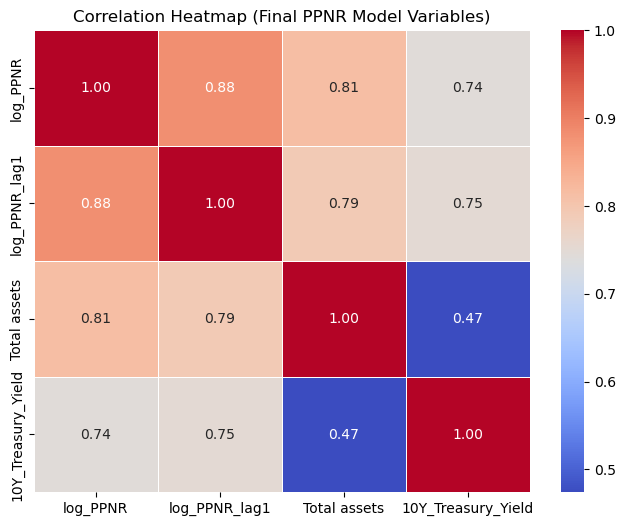

In [ ]:
# Final Heatmap

# select final variables
df_final = df_merged[
    [
        "log_PPNR",
        "log_PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
]

# correlation matrix
corr_final = df_final.corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_final,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Final PPNR Model Variables)")
plt.show()


In [ ]:
# Part IV : Final Model 


# final OLS model
import numpy as np
import statsmodels.api as sm

# log transform
df_merged["log_PPNR"] = np.log(df_merged["PPNR"])
df_merged["log_PPNR_lag1"] = np.log(df_merged["PPNR_lag1"])


X = df_merged[
    [
        "log_PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
].copy()

# scale assets
X.loc[:, "Total assets"] = X["Total assets"] / 1e6

X = sm.add_constant(X)
y = df_merged["log_PPNR"]

model_log = sm.OLS(y, X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_PPNR   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     84.49
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.64e-18
Time:                        21:11:58   Log-Likelihood:                 32.240
No. Observations:                  49   AIC:                            -56.48
Df Residuals:                      45   BIC:                            -48.91
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.2897      1

In [ ]:
# Final VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

X_vif = df_merged[
    [
        "log_PPNR_lag1",
        "Total assets",
        "10Y_Treasury_Yield"
    ]
].copy()

# apply same scaling as model
X_vif.loc[:, "Total assets"] = X_vif["Total assets"] / 1e6

# add constant
X_vif = sm.add_constant(X_vif)

# compute VIF
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# remove constant
vif = vif[vif["Variable"] != "const"]

# sort
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

             Variable          VIF
0               const  3580.227842
1       log_PPNR_lag1     5.190556
2        Total assets     2.931631
3  10Y_Treasury_Yield     2.501638


In [ ]:
# Part V : Model diagnostics

# check residual behavior
residuals = model_log.resid
fitted = model_log.fittedvalues

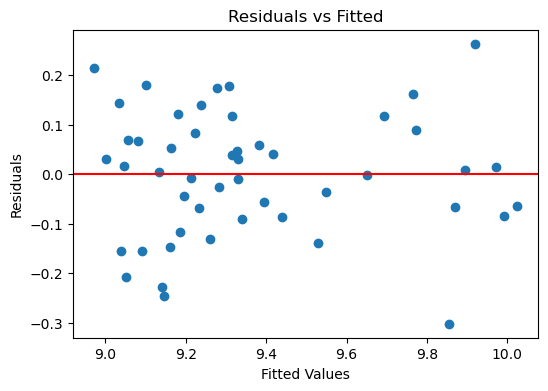

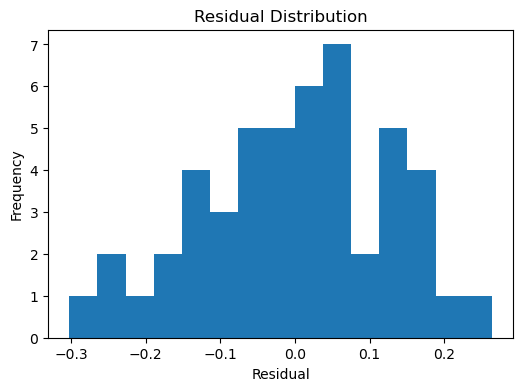

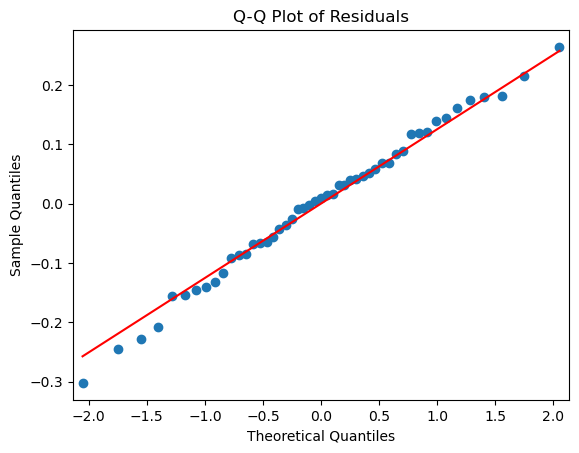

In [ ]:
import matplotlib.pyplot as plt

# residual vs. fitted plot

plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


# residual distribution
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=15)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


# Q-Q plot
import statsmodels.api as sm

sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

In [ ]:
# identify which quater for the outlier

# get absolute residuals
abs_res = residuals.abs()

# get top 2 largest
top2_idx = abs_res.nlargest(2).index

pd.DataFrame({
    "Quarter": df_model["Quarter"],
    "Actual_PPNR": y,
    "Predicted_PPNR": model_log.fittedvalues,
    "Residual": residuals
}).loc[top2_idx]

,Quarter,Actual_PPNR,Predicted_PPNR,Residual
42,2Q20,9.553079,9.855277,-0.302198
44,4Q20,10.184409,9.920383,0.264026


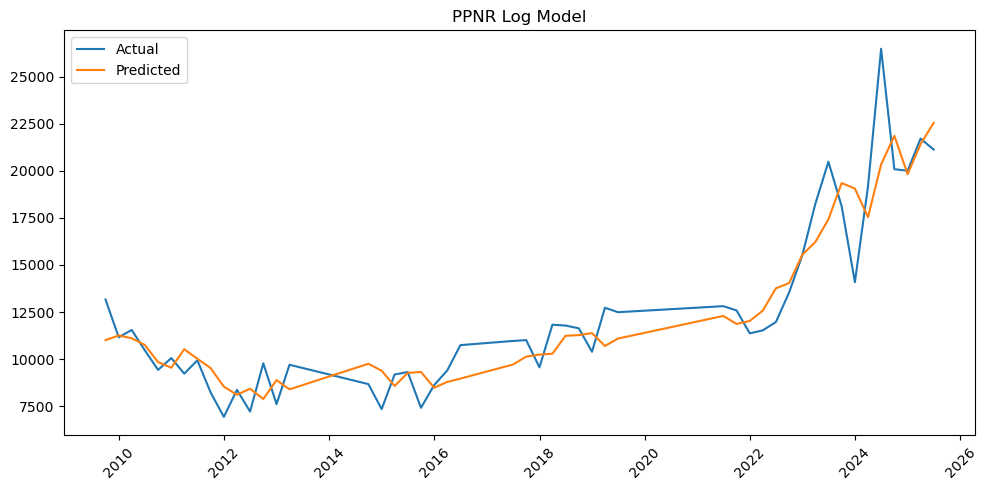

In [ ]:
df_merged["Pred_log"] = model_log.fittedvalues
df_merged["Pred_level"] = np.exp(df_merged["Pred_log"])

df_merged["Pred_smooth"] = df_merged["Pred_level"].rolling(3).mean()

plt.figure(figsize=(10,5))
plt.plot(df_merged["DATE"], df_merged["PPNR"], label="Actual")
plt.plot(df_merged["DATE"], df_merged["Pred_level"], label="Predicted")

plt.legend()
plt.title("PPNR Log Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()